## **Segundo Proyecto: Algoritmos de Búsqueda** 
**Curso:** Inteligencia Artificial - CC3085  



**Descripción General:**
En este proyecto se implementan y comparan diferentes algoritmos de búsqueda para resolver laberintos generados de forma aleatoria. Se estudian tanto algoritmos de generación de laberintos como técnicas de búsqueda clásicas en inteligencia artificial.

El objetivo principal es analizar el desempeño de algoritmos como BFS, DFS, Dijkstra y A*, evaluando métricas como:

- Nodos explorados
- Longitud del camino encontrado
- Tiempo de ejecución

Además, se generan múltiples escenarios experimentales para obtener conclusiones fundamentadas sobre cuál algoritmo es más eficiente en distintos contextos.

---

### ***Configuración Base***

Se importan las librerías necesarias y se define el grid $M \times N$, estructuras auxiliares para representar el laberinto y sus vecinos, y las constantes globales del proyecto.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import random
import time
import heapq
import pandas as pd
from collections import deque
from IPython.display import clear_output

#### ***Constantes Globales***

Para evitar inconsistencias entre implementaciones, todos los parámetros del proyecto se centralizan aquí.

**Parámetros**

- Tamaños de grid (según el PDF):
  - Demo Problema 1: $31 \times 41$
  - Problema 2 (prueba): $60 \times 80$ → se usa $61 \times 81$ para garantizar dimensiones impares
  - Problema 3 (benchmark): $45 \times 55$

- Número de simulaciones: $K = 25$

- Punto inicial: $(1,1)$  
- Punto final: $(\text{filas}-2, \text{columnas}-2)$

- Heurística A*: Distancia Manhattan

In [ ]:
# Tamaños de grid por problema 
FILAS_P1, COLS_P1 = 31, 41   # Demo generación
FILAS_P2, COLS_P2 = 61, 81   # Problema 2: 60x80 → impar
FILAS_P3, COLS_P3 = 45, 55   # Benchmark

K_SIMULACIONES = 25

# Colores para visualizaciones 
COLOR_PARED    = 0
COLOR_CAMINO   = 1
COLOR_VISITADO = 2
COLOR_RUTA     = 3
COLOR_INICIO   = 4
COLOR_FIN      = 5

CMAP_LABERINTO = mcolors.ListedColormap(['black', 'white', '#90CAF9', '#FFD600', '#00E676', '#FF1744'])
# 0=pared  1=camino  2=explorado  3=ruta  4=inicio  5=fin

def dibujar_laberinto(laberinto, titulo="Generando Laberinto...", pausa=0.05):
    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    plt.imshow(laberinto, cmap='binary')
    plt.title(titulo, fontsize=13)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()
    time.sleep(pausa)

### ***Generación de Laberintos***

Se implementan dos algoritmos con estructuras contrastantes para analizar su impacto en los algoritmos de búsqueda.

***Algoritmo de Prim***

Genera un laberinto haciendo crecer un Árbol de Expansión Mínima (MST) desde un punto inicial aleatorio. En cada paso, elige aleatoriamente una pared que separa una celda visitada de una no visitada y la elimina.

**Características:**
- Estructura orgánica, con crecimiento radial
- Muchos callejones sin salida y alta ramificación
- El camino solución suele ser tortuoso

**Impacto en búsqueda:**
Fuerza a BFS y DFS a explorar una gran cantidad de nodos antes de encontrar la salida.

In [19]:
def generar_prim(filas=FILAS_P1, columnas=COLS_P1, animar=False):
    r = filas    if filas    % 2 != 0 else filas    + 1
    c = columnas if columnas % 2 != 0 else columnas + 1

    laberinto = np.zeros((r, c), dtype=int)  # 0 = pared

    # Celda inicial aleatoria en posición impar
    start_r = random.randrange(1, r, 2)
    start_c = random.randrange(1, c, 2)
    laberinto[start_r, start_c] = 1

    # Lista de paredes candidatas
    paredes = []
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        nr, nc = start_r + dr, start_c + dc
        if 0 < nr < r-1 and 0 < nc < c-1:
            paredes.append((nr, nc, start_r, start_c))

    while paredes:
        idx = random.randint(0, len(paredes) - 1)
        pr, pc, vr, vc = paredes.pop(idx)

        dr, dc = pr - vr, pc - vc
        nr, nc = pr + dr, pc + dc

        if 0 < nr < r-1 and 0 < nc < c-1 and laberinto[nr, nc] == 0:
            laberinto[pr, pc] = 1  # romper pared
            laberinto[nr, nc] = 1  # marcar nueva celda

            for ddr, ddc in [(-1,0),(1,0),(0,-1),(0,1)]:
                nnr, nnc = nr + ddr, nc + ddc
                if 0 < nnr < r-1 and 0 < nnc < c-1 and laberinto[nnr, nnc] == 0:
                    paredes.append((nnr, nnc, nr, nc))

            if animar:
                dibujar_laberinto(laberinto, "Prim en construcción...", 0.01)

    # Garantizar entrada y salida
    laberinto[1, 1]      = 1
    laberinto[r-2, c-2]  = 1

    if animar:
        dibujar_laberinto(laberinto, "Laberinto Prim — Terminado", 0)

    return laberinto
    

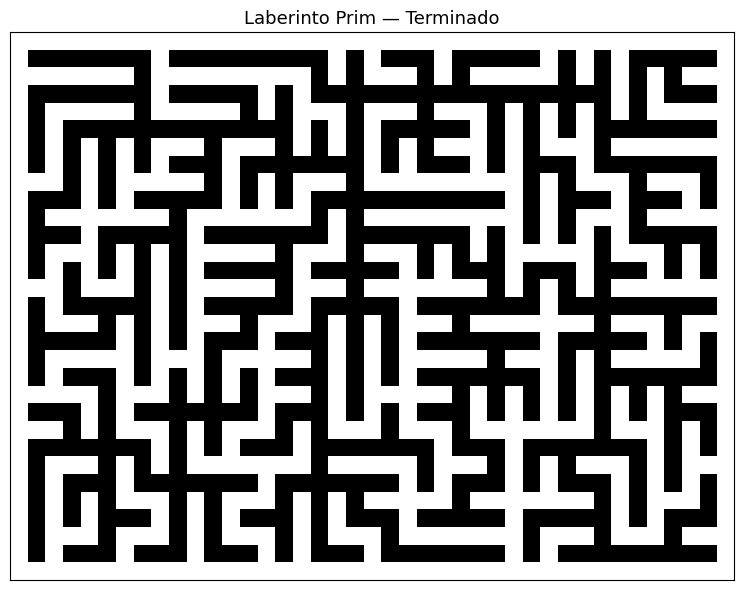

In [20]:
lab_prim = generar_prim(FILAS_P1, COLS_P1, animar=True)

***División Recursiva***

Parte de un espacio completamente abierto y lo subdivide recursivamente añadiendo muros con un hueco (puerta) en cada división. El enfoque es divide y vencerás.

**Características:**
- Pasillos largos y rectos, estructura tipo "bloques"
- Pocas ramificaciones, camino más directo
- Visualmente más simétrico

**Impacto en búsqueda:**
Favorece algoritmos heurísticos como A* ya que los pasillos rectos permiten seguir la heurística Manhattan con mayor efectividad.

In [21]:
def generar_division_recursiva(filas=FILAS_P1, columnas=COLS_P1, animar=False):

    r = filas    if filas    % 2 != 0 else filas    + 1
    c = columnas if columnas % 2 != 0 else columnas + 1

    # Iniciar con espacio abierto y borde de paredes
    laberinto = np.ones((r, c), dtype=int)
    laberinto[0, :]  = 0
    laberinto[-1, :] = 0
    laberinto[:, 0]  = 0
    laberinto[:, -1] = 0

    def dividir(rmin, rmax, cmin, cmax):
        if rmax - rmin < 2 or cmax - cmin < 2:
            return

        if (rmax - rmin) == (cmax - cmin):
            horizontal = random.choice([True, False])
        else:
            horizontal = (rmax - rmin) > (cmax - cmin)

        if horizontal:
            filas_par = list(range(rmin + 1, rmax, 2))
            if not filas_par: return
            muro_r = random.choice(filas_par)

            cols_impar = list(range(cmin, cmax + 1, 2))
            if not cols_impar: return
            paso_c = random.choice(cols_impar)

            laberinto[muro_r, cmin:cmax+1] = 0
            laberinto[muro_r, paso_c]      = 1

            if animar: dibujar_laberinto(laberinto, "División Recursiva...", 0.05)

            dividir(rmin,       muro_r - 1, cmin, cmax)
            dividir(muro_r + 1, rmax,       cmin, cmax)
        else:
            cols_par = list(range(cmin + 1, cmax, 2))
            if not cols_par: return
            muro_c = random.choice(cols_par)

            filas_impar = list(range(rmin, rmax + 1, 2))
            if not filas_impar: return
            paso_r = random.choice(filas_impar)

            laberinto[rmin:rmax+1, muro_c] = 0
            laberinto[paso_r,      muro_c] = 1

            if animar: dibujar_laberinto(laberinto, "División Recursiva...", 0.05)

            dividir(rmin, rmax, cmin,       muro_c - 1)
            dividir(rmin, rmax, muro_c + 1, cmax)

    dividir(1, r-2, 1, c-2)

    # Garantizar entrada y salida
    laberinto[1, 1]     = 1
    laberinto[r-2, c-2] = 1

    if animar:
        dibujar_laberinto(laberinto, "División Recursiva — Terminado", 0)

    return laberinto

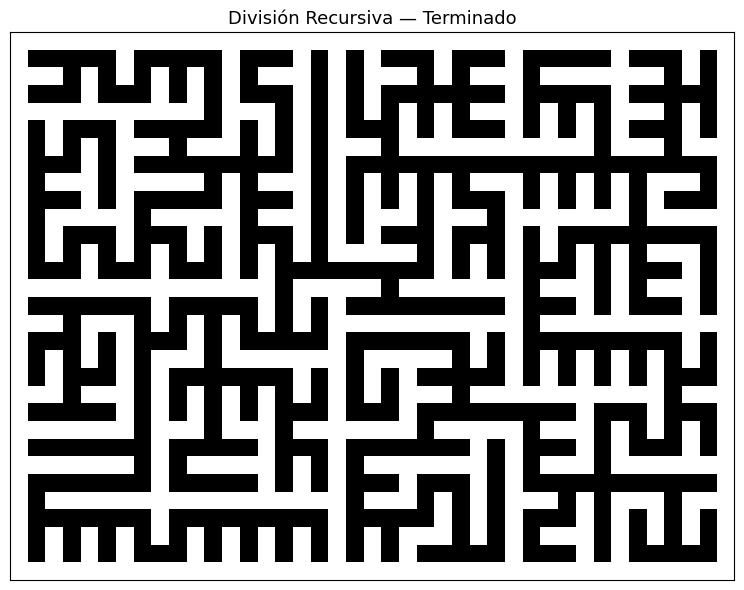

In [22]:
lab_div = generar_division_recursiva(FILAS_P1, COLS_P1, animar=True)

***Comparación Visual: Prim vs División Recursiva***

Se comparan los laberintos generados por ambos algoritmos para ilustrar las diferencias estructurales que impactan en los algoritmos de búsqueda.


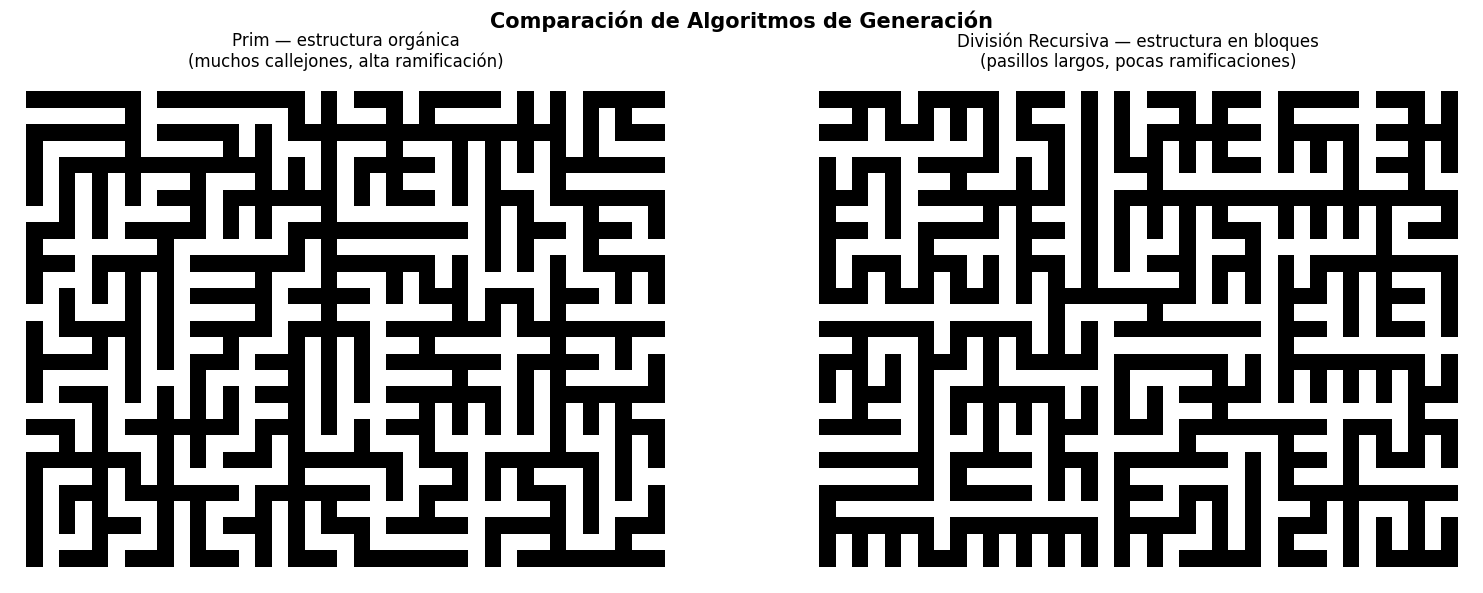

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(lab_prim, cmap='binary')
axes[0].set_title("Prim — estructura orgánica\n(muchos callejones, alta ramificación)", fontsize=12)
axes[0].axis('off')

axes[1].imshow(lab_div, cmap='binary')
axes[1].set_title("División Recursiva — estructura en bloques\n(pasillos largos, pocas ramificaciones)", fontsize=12)
axes[1].axis('off')

plt.suptitle("Comparación de Algoritmos de Generación", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### ***Algoritmos de Búsqueda***

Dado un laberinto de tamaño $60 \times 80$ (generado por los algoritmos de la Sección 1), se implementan los algoritmos de búsqueda para encontrar la ruta más corta entre:
- **Entrada:** celda $A = (1, 1)$
- **Salida:** celda $B = (\text{filas}-2, \text{columnas}-2)$



In [ ]:
# ─── Visualización animada de búsqueda ───────────────────────────────────────

def dibujar_busqueda(lab_viz, titulo='', pausa=0.01):
    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(16, 9))
    ax.imshow(lab_viz, cmap=CMAP_LABERINTO, vmin=0, vmax=5)
    ax.set_title(titulo, fontsize=13, pad=10)
    ax.axis('off')
    leyenda = [
        mpatches.Patch(color='black',   label='Pared'),
        mpatches.Patch(color='white',   label='Camino libre'),
        mpatches.Patch(color='#90CAF9', label='Explorado'),
        mpatches.Patch(color='#FFD600', label='Ruta optima'),
        mpatches.Patch(color='#00E676', label='Inicio'),
        mpatches.Patch(color='#FF1744', label='Fin'),
    ]
    ax.legend(handles=leyenda, loc='upper right', fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()
    if pausa > 0:
        time.sleep(pausa)


# ─── Algoritmo A* con heurística Manhattan ────────────────────────────────────

def resolver_astar(laberinto, inicio=(1, 1), fin=None, animar=False, pausa=0.003):
    """
    Resuelve el laberinto con A* (heuristica Manhattan).
    Retorna: (camino, nodos_explorados, tiempo_segundos)
    camino es None si no existe solucion.
    """
    filas, cols = laberinto.shape
    if fin is None:
        fin = (filas - 2, cols - 2)

    def h(nodo):
        return abs(nodo[0] - fin[0]) + abs(nodo[1] - fin[1])

    lab_viz = laberinto.copy().astype(float)
    lab_viz[inicio] = COLOR_INICIO
    lab_viz[fin]    = COLOR_FIN

    g_score   = {inicio: 0}
    came_from = {}
    visitados = set()
    contador  = 0
    heap      = [(h(inicio), contador, inicio)]

    nodos_explorados = 0
    t0 = time.time()

    while heap:
        _, _, actual = heapq.heappop(heap)

        if actual in visitados:
            continue
        visitados.add(actual)
        nodos_explorados += 1

        if actual == fin:
            camino = []
            nodo = fin
            while nodo in came_from:
                camino.append(nodo)
                nodo = came_from[nodo]
            camino.append(inicio)
            camino.reverse()

            for c in camino[1:-1]:
                lab_viz[c] = COLOR_RUTA

            tiempo = time.time() - t0
            if animar:
                dibujar_busqueda(
                    lab_viz,
                    f"A* — Laberinto resuelto  ·  Longitud: {len(camino)}  ·  "
                    f"Nodos explorados: {nodos_explorados}  ·  Tiempo: {tiempo:.4f}s",
                    pausa=0
                )
            return camino, nodos_explorados, tiempo

        if actual not in (inicio, fin):
            lab_viz[actual] = COLOR_VISITADO

        if animar and nodos_explorados % 150 == 0:
            dibujar_busqueda(
                lab_viz,
                f"A* explorando...  ·  Nodos explorados: {nodos_explorados}",
                pausa=pausa
            )

        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            vr, vc = actual[0] + dr, actual[1] + dc
            vecino = (vr, vc)
            if (0 <= vr < filas and 0 <= vc < cols
                    and laberinto[vr, vc] == 1
                    and vecino not in visitados):
                g_nuevo = g_score[actual] + 1
                if vecino not in g_score or g_nuevo < g_score[vecino]:
                    g_score[vecino] = g_nuevo
                    came_from[vecino] = actual
                    contador += 1
                    heapq.heappush(heap, (g_nuevo + h(vecino), contador, vecino))

    return None, nodos_explorados, time.time() - t0


# ─── Ejecución: Prim 60×80 ───────────────────────────────────────────────────

print("Generando laberinto Prim 60x80...")
lab_p2_prim = generar_prim(FILAS_P2, COLS_P2)

print("Resolviendo con A*...")
camino_prim, explorados_prim, tiempo_prim = resolver_astar(
    lab_p2_prim, animar=True, pausa=0.003
)

print(f"\n{'='*52}")
print(f"  Laberinto  : Prim  ({FILAS_P2-1} x {COLS_P2-1})")
print(f"  Longitud   : {len(camino_prim)} pasos")
print(f"  Explorados : {explorados_prim} nodos")
print(f"  Tiempo     : {tiempo_prim:.4f}s")
print(f"{'='*52}")


# ─── Ejecución: División Recursiva 60×80 ─────────────────────────────────────

print("\nGenerando laberinto Division Recursiva 60x80...")
lab_p2_div = generar_division_recursiva(FILAS_P2, COLS_P2)

print("Resolviendo con A*...")
camino_div, explorados_div, tiempo_div = resolver_astar(
    lab_p2_div, animar=True, pausa=0.003
)

print(f"\n{'='*52}")
print(f"  Laberinto  : Division Recursiva  ({FILAS_P2-1} x {COLS_P2-1})")
print(f"  Longitud   : {len(camino_div)} pasos")
print(f"  Explorados : {explorados_div} nodos")
print(f"  Tiempo     : {tiempo_div:.4f}s")
print(f"{'='*52}")


# ─── Comparación visual lado a lado ──────────────────────────────────────────

def lab_resuelto_viz(laberinto, camino):
    lab_viz = laberinto.copy().astype(float)
    inicio  = camino[0]
    fin     = camino[-1]
    for c in camino[1:-1]:
        lab_viz[c] = COLOR_RUTA
    lab_viz[inicio] = COLOR_INICIO
    lab_viz[fin]    = COLOR_FIN
    return lab_viz

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

axes[0].imshow(lab_resuelto_viz(lab_p2_prim, camino_prim),
               cmap=CMAP_LABERINTO, vmin=0, vmax=5)
axes[0].set_title(
    f"A* sobre Prim\nLongitud: {len(camino_prim)}  ·  Nodos: {explorados_prim}  ·  {tiempo_prim:.4f}s",
    fontsize=12)
axes[0].axis('off')

axes[1].imshow(lab_resuelto_viz(lab_p2_div, camino_div),
               cmap=CMAP_LABERINTO, vmin=0, vmax=5)
axes[1].set_title(
    f"A* sobre Division Recursiva\nLongitud: {len(camino_div)}  ·  Nodos: {explorados_div}  ·  {tiempo_div:.4f}s",
    fontsize=12)
axes[1].axis('off')

leyenda = [
    mpatches.Patch(color='black',   label='Pared'),
    mpatches.Patch(color='white',   label='Camino libre'),
    mpatches.Patch(color='#90CAF9', label='Explorado'),
    mpatches.Patch(color='#FFD600', label='Ruta optima'),
    mpatches.Patch(color='#00E676', label='Inicio'),
    mpatches.Patch(color='#FF1744', label='Fin'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=6, fontsize=10,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("A* — Comparacion entre tipos de laberinto (60 x 80)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# ─── Tabla resumen ────────────────────────────────────────────────────────────

resumen_p2 = pd.DataFrame({
    'Laberinto'         : ['Prim', 'Division Recursiva'],
    'Longitud camino'   : [len(camino_prim), len(camino_div)],
    'Nodos explorados'  : [explorados_prim,  explorados_div],
    'Tiempo (s)'        : [round(tiempo_prim, 4), round(tiempo_div, 4)],
})
display(resumen_p2)


### ***Comparación de Algoritmos***

Se evalúan los algoritmos en múltiples escenarios aleatorios.

***Benchmark***

Se generan $K=25$ laberintos de tamaño $45 \times 55$.

Para cada uno:
- Ejecutar BFS, DFS, Dijkstra y A*
- Medir:
  - Nodos explorados
  - Tiempo de ejecución
  - Longitud del camino

***Tablas***

Se construye una tabla con:
- Algoritmo
- Nodos explorados
- Tiempo
- Longitud del camino

Se calcula ranking por escenario y promedio general.

***Gráficas***

Se generan visualizaciones con matplotlib:

- Comparación de tiempos
- Comparación de nodos explorados
- Ranking promedio

Objetivo: identificar tendencias de desempeño.

### ***Conclusiones***
- ¿Qué algoritmo fue más rápido en promedio?
- ¿Cuál exploró menos nodos?
- ¿Cuál encontró mejores rutas?
- ¿Cómo afecta la estructura del laberinto (Prim vs División Recursiva)?
- ¿En qué casos falla DFS?
- ¿Cuándo A* supera claramente a los demás?